# **Review Sentiment Analysis**

In [ ]:
#Load Imports

#Data handling
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt

#Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

#NLP
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
from bs4 import BeautifulSoup

#ML
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight

#Pretrained model
from transformers import pipeline


#Ignore unnecessary warnings
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
#Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Load Dataset

file_path='/content/drive/MyDrive/Colab Notebooks/AI Final Project/zomato_reviews.csv'


reviews_df=pd.read_csv(file_path,index_col=0)
print(reviews_df.head())

   rating                                             review
0       5                                               nice
1       5  best biryani , so supportive staff of outlet ,...
2       4     delivery boy was very decent and supportive.👌👍
3       1  worst biryani i have tasted in my life, half o...
4       5  all food is good and tasty . will order again ...


In [ ]:
#Load Dataset and Handle Missing Values

file_path='/content/drive/MyDrive/Colab Notebooks/AI Final Project/zomato_reviews.csv'

#Load dataset
reviews_df=pd.read_csv(file_path,index_col=0)
print(reviews_df.head())

#Handle missing values
print('\n Find Missing Values \n',reviews_df.isnull().sum())

reviews_df['review']=reviews_df['review'].fillna('')                                     #Replace missing value with empty string

#Confirm Values Filled
print('\n Confirm Values are Filled \n', reviews_df.isnull().sum())


#Remove Stopwords and Clean Text
stop_words=set(stopwords.words('english'))

negation_words = {"not", "no", "nor", "never", "neither", "nobody", "nothing",
                  "nowhere", "hardly", "barely", "scarcely", "dont", "didnt",
                  "isnt", "wasnt", "wouldnt", "couldnt", "shouldnt", "cant",
                  "cannot", "wont", "havent", "hasnt", "hadnt", "aint",
                  "but", "however", "although", "though", "yet", "despite",
                  "except", "still", "only", "just"}
stop_words = stop_words - negation_words                                        #Removing negation from stoplist to preserve key words for sentiment

def clean_text(text):
  text=text.lower()
  text=BeautifulSoup(text,'html.parser').get_text()                             #Removing HTML tags
  text=re.sub(r'[^\x00-\x7F]+','',text)                                         #Prompt to Gemini 3 Flash: "how do i handle emojis when cleaning text"
  text=text.translate(str.maketrans('','',string.punctuation))                  #Remove Puncation
  words = text.split()
  filtered = [word for word in words                                            #Remove stopwords
              if word not in stop_words]
  return ' '.join(filtered)

reviews_df['clean_reviews'] = reviews_df['review'].apply(clean_text)
reviews_df['clean_reviews'] = reviews_df['clean_reviews'].replace('', 'no review text')             # Replace empty reviews with placeholder instead of removing them
reviews_df['clean_reviews'] = reviews_df['clean_reviews'].str.strip().replace('', 'no review text')
reviews_df = reviews_df.reset_index(drop=True)

#Confirm Cleaning
print('\n','Before Cleaning:', reviews_df['review'][1])
print('After Cleaning: ', reviews_df['clean_reviews'][1])

   rating                                             review
0       5                                               nice
1       5  best biryani , so supportive staff of outlet ,...
2       4     delivery boy was very decent and supportive.👌👍
3       1  worst biryani i have tasted in my life, half o...
4       5  all food is good and tasty . will order again ...

 Find Missing Values 
 rating    0
review    1
dtype: int64

 Confirm Values are Filled 
 rating    0
review    0
dtype: int64

 Before Cleaning: best biryani , so supportive staff of outlet , personalize my order on call as I say. full Paisa vasool 
After Cleaning:  best biryani supportive staff outlet personalize order call say full paisa vasool


In [ ]:
#Implementation of Hugging Face Pre-trained model: cardiffnlp/twitter-roberta-base-sentiment

sentiment_classifier = pipeline("sentiment-analysis", model= "cardiffnlp/twitter-roberta-base-sentiment")


hf_reviews = reviews_df['review'].tolist()                                      #Convert reviews to list for pipeline

hf_results = sentiment_classifier(
    hf_reviews,
    batch_size=64,
    truncation=True,
    max_length=512                                                              #Max tokens model can process
)

#Store sentiment results for each review
reviews_df['hf_sentiment'] = [result['label'] for result in hf_results]
reviews_df['hf_score'] = [result['score'] for result in hf_results]


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
#Categorization

#Categorizing Logic:
#1. If sentiment is Neutral (LABEL_1) always categorize as Mixed regardless of confidence
#2. If confidence >= 0.80 then trust sentiment score (Positive=Happy, Negative=Angry)
#3. If confidence < 0.80 then fall back to star rating (4-5=Happy, 3=Mixed, 1-2=Angry)

certainty = 0.80

def categorize_review(rating, hf_sentiment, hf_score):

    if hf_sentiment == 'LABEL_1':                                               #If neutral then always Mixed regardless of confidence
        return 'Mixed Review'

    if hf_score >= certainty:                                                   #If high confidence then trust sentiment
        if hf_sentiment == 'LABEL_2':                                           #LABEL_2 = Positive
            return 'Happy Review'
        else:                                                                   #LABEL_0 = Negative
            return 'Angry Review'

    else:                                                                       #If low confidence then use star rating
        if rating >= 4:
            return 'Happy Review'
        elif rating == 3:
            return 'Mixed Review'
        else:
            return 'Angry Review'

#Prompt to Gemini Flash 3: "How to call a function in a concise way to every row of the data"
reviews_df['category'] = reviews_df.apply(lambda row: categorize_review(row['rating'], row['hf_sentiment'], row['hf_score']), axis=1)

print(reviews_df['category'].value_counts())

category
Angry Review    1993
Happy Review    1968
Mixed Review    1518
Name: count, dtype: int64


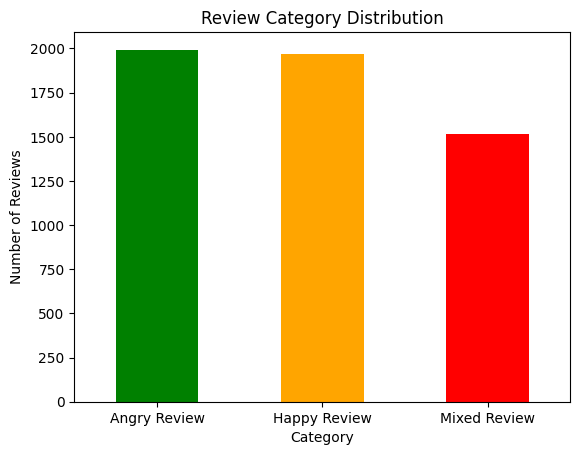

In [ ]:
#Class Distribution
reviews_df['category'].value_counts().plot(kind='bar', color=['green', 'orange', 'red'])
plt.title('Review Category Distribution')
plt.xlabel('Category')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.show()

#Converting category labels to integers for model training
category_mapping = {'Happy Review': 0, 'Mixed Review': 1, 'Angry Review': 2}
reviews_df['int_label'] = reviews_df['category'].map(category_mapping)

In [ ]:
#Split and Train the Data
feature= reviews_df['clean_reviews'].values
label = reviews_df['int_label'].values

val=0.1                                                                         #10% validation
random_seed = 42

train_features,val_features,train_labels,val_labels= train_test_split(feature,label,test_size=val,random_state=random_seed)


print('Train size:',len(train_features))
print('Validation size:',len(val_features))

Train size: 4931
Validation size: 548


In [ ]:
#Understanding the Data for Tokenization and Padding

#Prompt to Gemini Flash 3: "How do i find the best vocab size and max length for tokenization"

#Identifying max, mean and length of words in reviews
clean_rev_leng=reviews_df['clean_reviews'].str.split().str.len()
maxleng=clean_rev_leng.max()
meanleng=clean_rev_leng.mean()
print('Max:', maxleng, 'Mean:',meanleng)
print('95% of reviews are shorter than',(clean_rev_leng.quantile(0.95)),'words')   #95% of reviews


#Test tokenization to see vocab size
test_tokenizer = Tokenizer()
test_tokenizer.fit_on_texts(reviews_df['clean_reviews'])
print('Vocabulary size is:', (len(test_tokenizer.word_index)))

Max: 75 Mean: 7.166088702317941
95% of reviews are shorter than 20.0 words
Vocabulary size is: 5383


In [ ]:
#Assigning vocabulary size and max length
vocab_size = 7000
max_length = 30

#Tokenization and padding training data
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(train_features)                                          #Fit only on training data to avoid data leakage


#Convert into sequences
train_seq = tokenizer.texts_to_sequences(train_features)
val_seq = tokenizer.texts_to_sequences(val_features)



train_pad=pad_sequences(train_seq,maxlen=max_length,padding='post',truncating='post')
val_pad=pad_sequences(val_seq,maxlen=max_length,padding='post',truncating='post')

print('Training samples shape:', train_pad.shape)
print('Validation samples shape:', val_pad.shape)

Training samples shape: (4931, 30)
Validation samples shape: (548, 30)


**MODEL COMPARISON**

In [ ]:
#Prompt to Gemini Flash 3: "How do i keep my model results consistent in TensorFlow"
tf.random.set_seed(42)
np.random.seed(42)


#Baseline Model
baseline_model = keras.Sequential([
    keras.layers.Input(shape=(max_length,)),
    keras.layers.Embedding(vocab_size, 16),
    keras.layers.GlobalAveragePooling1D(),                                      # Prompt to Gemini Flash 3: "What is a simple pooling layer for short text classification"
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(3, activation='softmax')
])

baseline_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

baseline_history = baseline_model.fit(
    train_pad,
    train_labels,
    epochs=10,
    validation_data=(val_pad, val_labels))

Epoch 1/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4664 - loss: 1.0823 - val_accuracy: 0.5803 - val_loss: 1.0599
Epoch 2/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5997 - loss: 0.9954 - val_accuracy: 0.6095 - val_loss: 0.9143
Epoch 3/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7366 - loss: 0.8030 - val_accuracy: 0.7591 - val_loss: 0.7458
Epoch 4/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7777 - loss: 0.6626 - val_accuracy: 0.7646 - val_loss: 0.6719
Epoch 5/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7976 - loss: 0.5874 - val_accuracy: 0.7591 - val_loss: 0.6400
Epoch 6/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8144 - loss: 0.5381 - val_accuracy: 0.7682 - val_loss: 0.6236
Epoch 7/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8268 - loss: 0.5008 - val_accuracy: 0.7755 - val_loss: 0.6142
Epoch 8/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8363 - loss: 0.4702 - val_accuracy: 0.

In [ ]:
#Review Model - Improved
review_model = keras.Sequential([
    keras.layers.Input(shape=(max_length,)),
    keras.layers.Embedding(vocab_size, 32),
    keras.layers.Conv1D(64, 3, activation='relu'),  #Prompt to Gemini Flash 3: "My model is overfitting text what layer can i include to fix this "
    keras.layers.GlobalMaxPooling1D(),              #Prompt to Gemini Flash 3: "After adding Conv1D to my model what layer is best to use next
    keras.layers.Dropout(0.3),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(3, activation='softmax')
])

early_stop=keras.callbacks.EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)

review_model.compile(loss='sparse_categorical_crossentropy',
              optimizer=keras.optimizers.Adam(learning_rate=0.0005),            #Lower learning rate
              metrics=['accuracy'])


history = review_model.fit(train_pad, train_labels, epochs=20,
                    validation_data=(val_pad, val_labels),callbacks=[early_stop])

Epoch 1/20
155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4640 - loss: 1.0524 - val_accuracy: 0.5693 - val_loss: 0.9584
Epoch 2/20
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6966 - loss: 0.8145 - val_accuracy: 0.7555 - val_loss: 0.7064
Epoch 3/20
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7879 - loss: 0.6051 - val_accuracy: 0.7810 - val_loss: 0.6034
Epoch 4/20
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8215 - loss: 0.4940 - val_accuracy: 0.7883 - val_loss: 0.5707
Epoch 5/20
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8560 - loss: 0.4152 - val_accuracy: 0.7865 - val_loss: 0.5665
Epoch 6/20
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8808 - loss: 0.3564 - val_accuracy: 0.7865 - val_loss: 0.5775
Epoch 7/20
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8935 - loss: 0.3150 - val_accuracy: 0.7828 - val_loss: 0.5989
Epoch 8/20
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9033 - loss: 0.2787 - val_accuracy: 0

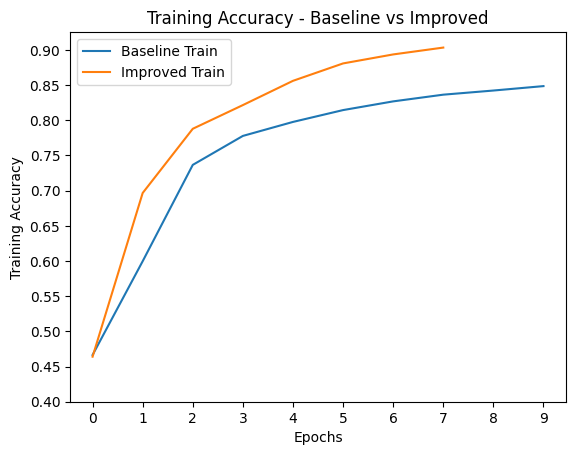

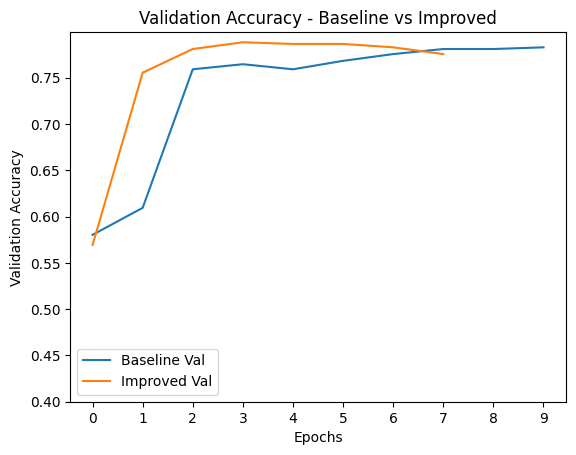

In [ ]:
#Training accuracy comparison
plt.plot(baseline_history.history['accuracy'], label='Baseline Train')          # Prompt to Gemini Flash 3: "How do i plot training vs validation accuracy for two models"
plt.plot(history.history['accuracy'], label='Improved Train')
plt.xlabel('Epochs')
plt.ylabel('Training Accuracy')
plt.title('Training Accuracy - Baseline vs Improved')
plt.xticks(range(0, max(len(baseline_history.history['accuracy']), len(history.history['accuracy']))))
plt.yticks(np.arange(0.40, 0.95, 0.05))
plt.legend()
plt.show()

#Validation accuracy comparison
plt.plot(baseline_history.history['val_accuracy'], label='Baseline Val')
plt.plot(history.history['val_accuracy'], label='Improved Val')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy - Baseline vs Improved')
plt.xticks(range(0, max(len(baseline_history.history['val_accuracy']), len(history.history['val_accuracy']))))
plt.yticks(np.arange(0.40, 0.8, 0.05))
plt.legend()
plt.show()

In [ ]:
#Model Comparison Summary
print("MODEL COMPARISON\n")

baseline_accuracy = round(max(baseline_history.history['val_accuracy']) * 100, 2)
improved_accuracy = round(max(history.history['val_accuracy']) * 100, 2)

print("Baseline Model  - Best Validation Accuracy:", baseline_accuracy, "%")
print("Improved Model  - Best Validation Accuracy:", improved_accuracy, "%")

MODEL COMPARISON

Baseline Model  - Best Validation Accuracy: 78.28 %
Improved Model  - Best Validation Accuracy: 78.83 %


**EVALUATION AND ERROR ANALYSIS**

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

Baseline Model
              precision    recall  f1-score   support

       Happy       0.76      0.81      0.79       189
       Mixed       0.78      0.76      0.77       157
       Angry       0.81      0.77      0.79       202

    accuracy                           0.78       548
   macro avg       0.78      0.78      0.78       548
weighted avg       0.78      0.78      0.78       548

Improved Model
              precision    recall  f1-score   support

       Happy       0.75      0.83      0.79       189
       Mixed       0.77      0.76      0.77       157
       Angry       0.84      0.77      0.80       202

    accuracy                           0.79       548
   macro avg       0.79      0.79      0.79       548
weighted avg       0.79      0.79      0.79       548



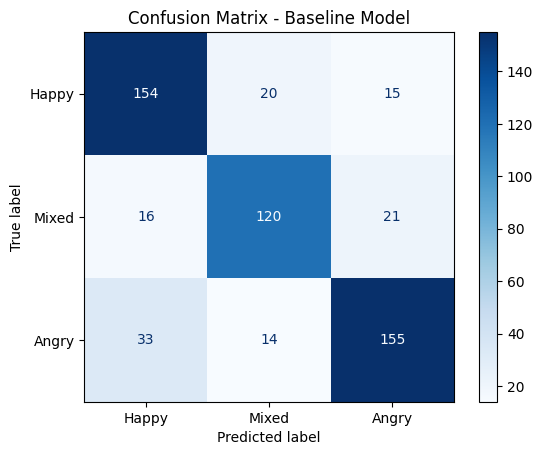

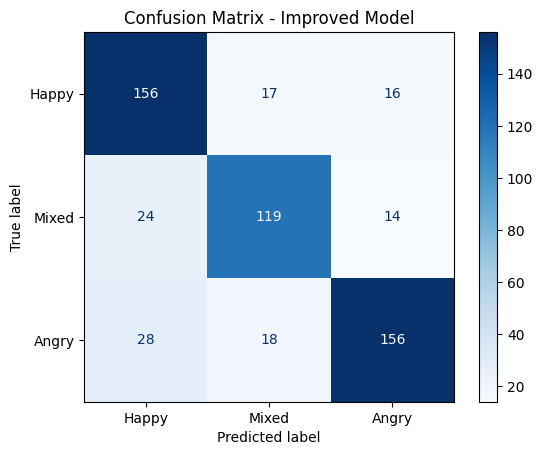

In [ ]:
#Evaluation

category_names = ['Happy', 'Mixed', 'Angry']

#Generate predictions
baseline_pred = np.argmax(baseline_model.predict(val_pad), axis=1)
improved_pred = np.argmax(review_model.predict(val_pad), axis=1)

#Classification Reports - Precision, Recall and F1 Score for each class
print("\nBaseline Model")
print(classification_report(val_labels, baseline_pred, target_names=category_names))

print("Improved Model")
print(classification_report(val_labels, improved_pred, target_names=category_names))

#Confusion Matrix - Baseline
c_matrix_baseline = confusion_matrix(val_labels, baseline_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=c_matrix_baseline, display_labels=category_names)
disp.plot(cmap='Blues')
disp.ax_.set_title('Confusion Matrix - Baseline Model')
plt.show()

#Confusion Matrix - Improved
c_matrix_improved = confusion_matrix(val_labels, improved_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=c_matrix_improved, display_labels=category_names)
disp.plot(cmap='Blues')
disp.ax_.set_title('Confusion Matrix - Improved Model')
plt.show()

In [ ]:
#Error Analysis
print("Error Analysis - Improved Model\n")

#Prompt to Gemini Flash 3: "How do i find and display misclassified examples from my model predictions"
errors = []
for i in range(len(val_labels)):
    if improved_pred[i] != val_labels[i]:
        errors.append({
            'review': val_features[i],
            'actual': category_names[val_labels[i]],
            'predicted': category_names[improved_pred[i]]
        })

errors_df = pd.DataFrame(errors)

#Mistake examples
print("\nAngry reviews misclassified as Mixed")
angry_reviews = errors_df[errors_df['actual'] == 'Angry']
angry_as_mixed = angry_reviews[angry_reviews['predicted'] == 'Mixed'].head(3)
print(angry_as_mixed[['review', 'actual', 'predicted']].to_string())

print("\nHappy reviews misclassified as Mixed")
happy_reviews = errors_df[errors_df['actual'] == 'Happy']
happy_as_mixed = happy_reviews[happy_reviews['predicted'] == 'Mixed'].head(3)
print(happy_as_mixed[['review', 'actual', 'predicted']].to_string())


#Overall error summary
total = len(val_labels)
total_errors = sum(improved_pred != val_labels)
error_rate = total_errors / total * 100


print('\nOverall Error Summary')
print("Total errors:", total_errors, "out of", len(val_labels), "validation reviews")
print("Error rate:", round(error_rate,2), "%")
print("Correct predictions:", len(val_labels) - total_errors, "out of", len(val_labels))

Error Analysis - Improved Model


Angry reviews misclassified as Mixed
                                                          review actual predicted
4                                         chutney sweet big turn  Angry     Mixed
8                                                 no review text  Angry     Mixed
10  highly unsetisfectry uncooked unbeatable foodnever going try  Angry     Mixed

Happy reviews misclassified as Mixed
                                        review actual predicted
0                               no review text  Happy     Mixed
6                              beautiful tesat  Happy     Mixed
34  ghar pe late pohcha iske liye cancel order  Happy     Mixed

Overall Error Summary
Total errors: 117 out of 548 validation reviews
Error rate: 21.35 %
Correct predictions: 431 out of 548


**AUTOMATED RESPONSE SYSTEM**

In [ ]:

print("Automated Response System\n")

def generate_customer_response(category):
    if category == 'Happy Review':
        return "Thank you so much for your kind words! We are thrilled you had a great experience and hope to see you again soon!"
    elif category == 'Mixed Review':
        return "Thank you for your feedback. We are sorry your experience was not perfect. Please email us at support@restaurant.com so we can make it right!"
    else:
        return None

def generate_manager_alert(category, review):
    if category == 'Angry Review':
        return "*** MANAGER ALERT *** Angry review detected - Human intervention required. Review: " + review
    else:
        return None

#Manual input
user_review = input("Enter a review: ")
user_rating = int(input("Enter star rating (1-5): "))

#Prompt to Gemini Flash 3: "How do i take a manual input and run it through my trained model"
cleaned_review = clean_text(user_review)
seq = tokenizer.texts_to_sequences([cleaned_review])
padded = pad_sequences(seq, maxlen=max_length, padding='post', truncating='post')

#Model prediction
prediction = review_model.predict(padded, verbose=0)
predicted_index = np.argmax(prediction)
predicted_category = category_names[predicted_index] + ' Review'

#Apply confidence threshold with star rating fallback
hf_result = sentiment_classifier(user_review, truncation=True, max_length=512)
final_category = categorize_review(user_rating, hf_result[0]['label'], hf_result[0]['score'])

#Show model logic
hf_confidence = hf_result[0]['score']
if hf_confidence >= certainty:
    decision_basis = "Sentiment Score (Confidence: " + str(round(hf_confidence * 100, 2)) + "%)"
else:
    decision_basis = "Star Rating (Sentiment confidence too low: " + str(round(hf_confidence * 100, 2)) + "%)"


print("\nReview:", user_review)
print("Star Rating:", user_rating)
print("Decision Based On:", decision_basis)
print("Predicted Category:", final_category)

response = generate_customer_response(final_category)
alert = generate_manager_alert(final_category, user_review)

if response:
    print("Customer Response:", response)
if alert:
    print(alert)


Automated Response System

Enter a review: it was okay
Enter star rating (1-5): 3

Review: it was okay
Star Rating: 3
Decision Based On: Star Rating (Sentiment confidence too low: 79.04%)
Predicted Category: Mixed Review
Customer Response: Thank you for your feedback. We are sorry your experience was not perfect. Please email us at support@restaurant.com so we can make it right!
